# Khmer Word Embeddings and Neural Language Modeling using Temples Corpus

**Course:** Natural Language Processing  
**Program:** Master of Data Science  
**Institute:** Institute of Technology of Cambodia  
**Project:** Mini Project 3 - Word Embeddings

This notebook builds Khmer word embeddings from `temples.txt` using a skip-gram model with negative sampling. It also builds an n-gram language-model baseline and two neural language models for next-word prediction. The notebook is written to be reproducible, beginner-friendly, and professor-facing.

## 2. Professor Requirement Checklist

| Requirement | Implementation | Status |
|---|---|---|
| Khmer corpus | Loads `data/temples.txt`, with `temples.txt` fallback | Completed |
| Khmer tokenization | Tries `khmer-nltk`/`khmernltk`, then dictionary maximum matching and regex fallback | Completed |
| Ignore frequency < 10 | `MIN_FREQ = 10` for the main vocabulary | Completed |
| Embedding dimension = 50 | `EMBEDDING_DIM = 50` | Completed |
| Context window = +/-4 | `WINDOW_SIZE = 4` | Completed |
| Negative sampling k = 2 | `NEGATIVE_SAMPLES = 2` | Completed |
| PCA 2D visualization | PCA with `n_components=2` for embeddings | Completed |
| Neural LM n = 5 | Uses previous `N_CONTEXT = 5` words | Completed |
| Hidden layer h = 512 | `HIDDEN_SIZE = 512` | Completed |
| Scratch embedding neural LM | Second neural LM learns embeddings from scratch | Completed |
| Comparison | Tables and interpretation compare all models | Completed |
| 4-page report | Summary section included at the end | Completed |

## 3. Alignment with NLP Lessons 01-08

| Lesson | Connection in this Notebook |
|---|---|
| 01-02 Intro + RE | NLP transforms unstructured Khmer text into structured tokens and vectors. Regular expressions help clean references, URLs, punctuation, and noise. |
| 03 Text Preprocessing | Khmer tokenization, token/type/vocabulary, cleaning, normalization, and Khmer word boundary challenges are handled directly. |
| 04 String Comparison | Edit distance compares strings character by character, while embedding similarity compares words by context and meaning. |
| 05 N-gram Model | The baseline predicts the next word using the Markov assumption and previous words. |
| 06 Zero-probability N-grams | Add-one smoothing handles unseen n-grams and supports perplexity calculation. |
| 07 Text Classification | Skip-gram with negative sampling is a binary classifier: real center-context pair = 1, negative sampled pair = 0. |
| 08 Word Meaning | Vector semantics, co-occurrence, cosine similarity, and PCA visualization show word meaning. |

## 4. Environment Setup

Install packages if needed:

```bash
pip install khmer-nltk torch scikit-learn plotly pandas numpy
```

The notebook uses only relative paths so it can run on another computer after cloning or downloading the project.

In [1]:
from pathlib import Path
import os
import re
import random
import math
import json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

current_path = Path.cwd()
if not (current_path / "data" / "temples.txt").exists():
    if (current_path.parent / "data" / "temples.txt").exists():
        os.chdir(current_path.parent)

print("Working directory:", Path.cwd())
print("Imports completed successfully.")

Working directory: d:\M-DAS\Semerster 2\NLP\NLP-Mini-Project-3-Khmer-Embeddings-10-10
Imports completed successfully.


## 5. Reproducibility Settings

These constants match the project requirements. The code detects GPU if available, but CPU is enough for this mini project.

In [2]:
RANDOM_SEED = 42
EMBEDDING_DIM = 50
WINDOW_SIZE = 4
NEGATIVE_SAMPLES = 2
MIN_FREQ = 10
N_CONTEXT = 5
HIDDEN_SIZE = 512
BATCH_SIZE = 128
EPOCHS_SKIPGRAM = 20
EPOCHS_LM = 20
LEARNING_RATE = 0.001

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cpu


## 6. Load Temples Corpus

The corpus is loaded from `data/temples.txt`. If that file is not found, the notebook tries `temples.txt` in the project root.

In [3]:
candidate_paths = [Path("data") / "temples.txt", Path("temples.txt")]
corpus_path = None

for path in candidate_paths:
    if path.exists():
        corpus_path = path
        break

if corpus_path is None:
    raise FileNotFoundError("Could not find data/temples.txt or temples.txt")

raw_text = corpus_path.read_text(encoding="utf-8")

print("File path used:", corpus_path)
print("Character count:", len(raw_text))
print("First 500 characters:")
print(raw_text[:500])

File path used: data\temples.txt
Character count: 45920
First 500 characters:
ប្រាសាទអង្គរវត្ត ឬប្រាសាទអង្គរតូចមានទីតាំងស្ថិតនៅភាគខាងជើងនៃក្រុងសៀមរាបនៃខេត្តសៀមរាប។ ប្រាសាទអង្គរវត្តជាប្រាសាទព្រហ្មញ្ញសាសនាធំបំផុត និងជាវិមានសាសនាដ៏ធំបំផុតនៅក្នុងលោក។ ប្រាសាទនេះត្រូវបានកសាងឡើងដោយព្រះបាទសូរ្យវរ្ម័នទី២ ដែលជាស្នាដៃដ៏ធំអស្ចារ្យ និងមានឈ្មោះល្បីល្បាញរន្ទឺសុះសាយទៅគ្រប់ទិសទីលើពិភពលោក។ ប្រាសាទនេះសាងសង់ឡើងនៅដើមសតវត្សទី១២ ដែលស្ថិតនៅក្នុងរាជធានី[[យសោធរបុរៈ។ ប្រាសាទអង្គរវត្តជាប្រាសាទកសាងឡើង ដើម្បីឧទ្ទិសដល់ព្រះវិស្ណុ។ ប្រាសាទនេះជាប្រាសាទដែលនៅគង់វង្សល្អបំផុតនៅក្នុងតំបន់អង្គរ។ប្រាសាទអង្គរវត្ត


## 7. Text Cleaning and Normalization

This step removes references, URLs, and unnecessary markup while preserving Khmer text.

In [4]:
def clean_text(text):
    cleaned = text
    cleaned = re.sub(r"https?://\S+|www\.\S+", " ", cleaned)
    cleaned = re.sub(r"\[[^\]]{0,20}\]", " ", cleaned)
    cleaned = re.sub(r"\(\s*\)", " ", cleaned)
    cleaned = cleaned.replace("\u200b", "")
    cleaned = cleaned.replace("\ufeff", "")
    cleaned = re.sub(r"\s+", " ", cleaned)
    return cleaned.strip()

cleaned_text = clean_text(raw_text)

print("Before cleaning sample:")
print(raw_text[:300])
print()
print("After cleaning sample:")
print(cleaned_text[:300])
print()
print("Characters before:", len(raw_text))
print("Characters after:", len(cleaned_text))

Before cleaning sample:
ប្រាសាទអង្គរវត្ត ឬប្រាសាទអង្គរតូចមានទីតាំងស្ថិតនៅភាគខាងជើងនៃក្រុងសៀមរាបនៃខេត្តសៀមរាប។ ប្រាសាទអង្គរវត្តជាប្រាសាទព្រហ្មញ្ញសាសនាធំបំផុត និងជាវិមានសាសនាដ៏ធំបំផុតនៅក្នុងលោក។ ប្រាសាទនេះត្រូវបានកសាងឡើងដោយព្រះបាទសូរ្យវរ្ម័នទី២ ដែលជាស្នាដៃដ៏ធំអស្ចារ្យ និងមានឈ្មោះល្បីល្បាញរន្ទឺសុះសាយទៅគ្រប់ទិសទីលើពិភពលោក។ ប្រ

After cleaning sample:
ប្រាសាទអង្គរវត្ត ឬប្រាសាទអង្គរតូចមានទីតាំងស្ថិតនៅភាគខាងជើងនៃក្រុងសៀមរាបនៃខេត្តសៀមរាប។ ប្រាសាទអង្គរវត្តជាប្រាសាទព្រហ្មញ្ញសាសនាធំបំផុត និងជាវិមានសាសនាដ៏ធំបំផុតនៅក្នុងលោក។ ប្រាសាទនេះត្រូវបានកសាងឡើងដោយព្រះបាទសូរ្យវរ្ម័នទី២ ដែលជាស្នាដៃដ៏ធំអស្ចារ្យ និងមានឈ្មោះល្បីល្បាញរន្ទឺសុះសាយទៅគ្រប់ទិសទីលើពិភពលោក។ ប្រ

Characters before: 45920
Characters after: 45590


**Interpretation:** Cleaning removes technical noise such as references and repeated spaces. It does not remove Khmer content because Khmer words are the main information source for this project.

## 8. Khmer Tokenization

Khmer does not always separate words with spaces, so `.split()` is not enough. This tokenizer tries three levels:

1. `khmer-nltk` or `khmernltk` word tokenizer.
2. A custom temple-domain dictionary with longest-match segmentation.
3. Regex-based Khmer chunk fallback for unknown text.

In [5]:
KHMER_WORDS = [
    "ប្រាសាទអង្គរវត្ត", "អង្គរវត្ត", "ប្រាសាទ", "អង្គរ", "វត្ត", "សៀមរាប",
    "ខេត្ត", "ក្រុង", "ព្រះបាទ", "ព្រះ", "សូរ្យវរ្ម័ន", "វិស្ណុ", "សាសនា",
    "ព្រហ្មញ្ញសាសនា", "ព្រះពុទ្ធសាសនា", "ខ្មែរ", "កម្ពុជា", "ថ្ម", "ចម្លាក់",
    "អប្សរា", "ស្ថាបត្យកម្ម", "ភ្នំ", "សុមេរុ", "រាជធានី", "អាណាចក្រ",
    "សតវត្ស", "ប្រវត្តិសាស្ត្រ", "បន្ទាយស្រី", "កោះកេរ", "ទេវតា", "នគរ",
    "រាជា", "ទន្លេ", "កំពូល", "ជញ្ជាំង", "កណ្តាល", "ទិស", "លោក", "ដី",
    "មហា", "បុរាណ", "សំណង់", "សិល្បៈ", "ទេសភាព", "កសាង", "ប្រើប្រាស់",
]

KHMER_WORDS = sorted(set(KHMER_WORDS), key=len, reverse=True)
KHMER_RE = re.compile(r"[\u1780-\u17FF]+")
SPLIT_RE = re.compile(r"[\s,;:()\[\]{}\"'«»“”‘’។៕?!…\-/]+")

def get_khmer_nltk_tokenizer():
    word_tokenize = None
    source = None
    try:
        from khmer_nltk import word_tokenize as imported_word_tokenize
        word_tokenize = imported_word_tokenize
        source = "khmer_nltk.word_tokenize"
    except Exception:
        try:
            from khmernltk import word_tokenize as imported_word_tokenize
            word_tokenize = imported_word_tokenize
            source = "khmernltk.word_tokenize"
        except Exception:
            word_tokenize = None
            source = None
    return word_tokenize, source

def split_unknown_khmer_chunk(chunk, max_len=6):
    pieces = []
    start = 0
    while start < len(chunk):
        end = start + max_len
        pieces.append(chunk[start:end])
        start = end
    return pieces

def dictionary_max_match(segment):
    tokens = []
    i = 0
    while i < len(segment):
        matched_word = None
        for word in KHMER_WORDS:
            if segment.startswith(word, i):
                matched_word = word
                break
        if matched_word is not None:
            tokens.append(matched_word)
            i = i + len(matched_word)
        else:
            match = KHMER_RE.match(segment, i)
            if match:
                unknown_chunk = match.group(0)
                for piece in split_unknown_khmer_chunk(unknown_chunk):
                    tokens.append(piece)
                i = match.end()
            else:
                i = i + 1
    return tokens

def fallback_tokenize(text):
    tokens = []
    rough_segments = SPLIT_RE.split(text)
    for segment in rough_segments:
        if segment == "":
            continue
        khmer_parts = KHMER_RE.findall(segment)
        for part in khmer_parts:
            part_tokens = dictionary_max_match(part)
            for token in part_tokens:
                tokens.append(token)
    return tokens

def tokenize_khmer_text(text):
    word_tokenize, tokenizer_source = get_khmer_nltk_tokenizer()
    tokens = []
    if word_tokenize is not None:
        try:
            candidate_tokens = word_tokenize(text)
            if isinstance(candidate_tokens, str):
                candidate_tokens = candidate_tokens.split()
            for token in candidate_tokens:
                token = str(token).strip()
                if token != "":
                    tokens.append(token)
            if len(tokens) > 0:
                return tokens, tokenizer_source
        except Exception as error:
            print("khmer-nltk failed, using fallback tokenizer:", error)

    tokens = fallback_tokenize(text)
    return tokens, "dictionary_max_match_regex_fallback"

all_tokens, tokenizer_used = tokenize_khmer_text(cleaned_text)
token_counts_before_filter = Counter(all_tokens)
token_lengths = [len(token) for token in all_tokens]

print("Tokenizer used:", tokenizer_used)
print("First 100 tokens:")
print(all_tokens[:100])
print("Total tokens:", len(all_tokens))
print("Unique tokens:", len(set(all_tokens)))
print("Average token length:", round(float(np.mean(token_lengths)), 2))
print("Top 30 tokens:")
print(token_counts_before_filter.most_common(30))

very_long_tokens = []
for token in all_tokens:
    if len(token) > 25:
        very_long_tokens.append(token)

print("Number of very long tokens with length > 25:", len(very_long_tokens))
print("Sample very long tokens:", very_long_tokens[:10])

| 2026-06-15 11:26:56,700 | INFO | khmer-nltk | Loaded model from C:\Users\MSI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\khmernltk\word_tokenize\sklearn_crf_ner_10000.sav |


Tokenizer used: khmernltk.word_tokenize
First 100 tokens:
['ប្រាសាទ', 'អង្គរវត្ត', 'ឬ', 'ប្រាសាទ', 'អង្គរ', 'តូច', 'មាន', 'ទីតាំង', 'ស្ថិត', 'នៅ', 'ភាគ', 'ខាងជើង', 'នៃ', 'ក្រុង', 'សៀមរាប', 'នៃ', 'ខេត្ត', 'សៀមរាប', '។', 'ប្រាសាទ', 'អង្គរវត្ត', 'ជា', 'ប្រាសាទ', 'ព្រហ្មញ្ញ', 'សាសនា', 'ធំ', 'បំផុត', 'និង', 'ជា', 'វិមាន', 'សាសនា', 'ដ៏', 'ធំ', 'បំផុត', 'នៅក្នុង', 'លោក', '។', 'ប្រាសាទ', 'នេះ', 'ត្រូវបាន', 'កសាងឡើង', 'ដោយ', 'ព្រះបាទ', 'សូរ្យ', 'វរ្ម័ន', 'ទី២', 'ដែល', 'ជា', 'ស្នាដៃ', 'ដ៏', 'ធំ', 'អស្ចារ្យ', 'និង', 'មាន', 'ឈ្មោះ', 'ល្បីល្បាញ', 'រន្ទឺ', 'សុះ', 'សាយ', 'ទៅ', 'គ្រប់', 'ទិសទី', 'លើ', 'ពិភពលោក', '។', 'ប្រាសាទ', 'នេះ', 'សាងសង់', 'ឡើង', 'នៅ', 'ដើម', 'សតវត្ស', 'ទី', '១២', 'ដែល', 'ស្ថិត', 'នៅក្នុង', 'រាជធានី', '[[យ', 'សោធរ', 'បុរៈ', '។', 'ប្រាសាទ', 'អង្គរវត្ត', 'ជា', 'ប្រាសាទ', 'កសាងឡើង', 'ដើម្បី', 'ឧទ្ទិស', 'ដល់', 'ព្រះវិស្ណុ', '។', 'ប្រាសាទ', 'នេះ', 'ជា', 'ប្រាសាទ', 'ដែល', 'នៅ', 'គង់វង្ស', 'ល្អ']
Total tokens: 9802
Unique tokens: 2227
Average token length: 4.49
Top 30 tokens:
[('។', 338

**Interpretation:** A good Khmer tokenizer should produce many short, meaningful Khmer tokens. If many very long tokens remain, it means tokenization still needs improvement. This notebook uses `khmernltk` when available and keeps a dictionary/regex fallback so the project does not collapse into sentence-length tokens.

## 9. Data Quality Checking

This section checks missing tokens, duplicate lines, token length outliers, punctuation, numbers, and noisy symbols.

In [6]:
KHMER_PUNCTUATION = [
    "។", "៕", "៖", "ៗ", "៘", "៙", "៚", "៛",
    ",", ".", "!", "?", ":", ";",
    "(", ")", "[", "]", "{", "}",
    "\"", "'", "“", "”", "‘", "’",
    "-", "–", "—", "_", "/", "\\", "|"
]

def is_number_only(token):
    token = str(token).strip()
    if token == "":
        return False

    khmer_digits = "០១២៣៤៥៦៧៨៩"
    english_digits = "0123456789"

    for char in token:
        if char not in khmer_digits and char not in english_digits:
            return False

    return True

def has_khmer_character(token):
    for char in token:
        if "\u1780" <= char <= "\u17FF":
            return True
    return False

def is_punctuation_token(token):
    token = str(token).strip()
    if token == "":
        return False
    if token in KHMER_PUNCTUATION:
        return True
    for char in token:
        if char not in KHMER_PUNCTUATION:
            return False
    return True

raw_lines = raw_text.splitlines()
empty_lines = 0
for line in raw_lines:
    if line.strip() == "":
        empty_lines = empty_lines + 1

sentence_parts = re.split(r"[។៕?!\n]+", raw_text)
sentence_counts = Counter()
for sentence in sentence_parts:
    clean_sentence = sentence.strip()
    if clean_sentence != "":
        sentence_counts[clean_sentence] = sentence_counts[clean_sentence] + 1

duplicate_sentences = 0
for sentence, count in sentence_counts.items():
    if count > 1:
        duplicate_sentences = duplicate_sentences + count - 1

punctuation_tokens = 0
number_tokens = 0
non_khmer_tokens = 0
for token in all_tokens:
    if is_punctuation_token(token):
        punctuation_tokens = punctuation_tokens + 1
    elif is_number_only(token):
        number_tokens = number_tokens + 1
    elif not has_khmer_character(token):
        non_khmer_tokens = non_khmer_tokens + 1

rare_token_types = 0
high_frequency_token_types = 0
for token, count in token_counts_before_filter.items():
    if count < MIN_FREQ:
        rare_token_types = rare_token_types + 1
    if count >= 100:
        high_frequency_token_types = high_frequency_token_types + 1

quality_rows = [
    {"Issue": "Empty tokens", "Count": all_tokens.count(""), "Explanation": "Tokens with no characters", "Action Taken": "Removed during filtering"},
    {"Issue": "Punctuation tokens", "Count": punctuation_tokens, "Explanation": "Includes Khmer punctuation such as ។ and ៗ", "Action Taken": "Removed before vocabulary construction"},
    {"Issue": "Number-only tokens", "Count": number_tokens, "Explanation": "Arabic or Khmer digits only", "Action Taken": "Removed before vocabulary construction"},
    {"Issue": "Non-Khmer/noisy tokens", "Count": non_khmer_tokens, "Explanation": "Tokens without Khmer characters", "Action Taken": "Removed before vocabulary construction"},
    {"Issue": "Very long tokens > 25", "Count": len(very_long_tokens), "Explanation": "May indicate tokenization problems or long compounds", "Action Taken": "Reported and abnormal tokens are filtered if too long"},
    {"Issue": "Duplicate lines/sentences", "Count": duplicate_sentences, "Explanation": "Repeated sentence-like text", "Action Taken": "Reported; repeated word evidence is still useful for frequency"},
    {"Issue": "Rare token types", "Count": rare_token_types, "Explanation": "Frequency below MIN_FREQ", "Action Taken": "Mapped to <UNK> by the required MIN_FREQ=10 rule"},
    {"Issue": "High-frequency token types", "Count": high_frequency_token_types, "Explanation": "Very common corpus words", "Action Taken": "Kept if they are useful Khmer words"},
]

quality_df = pd.DataFrame(quality_rows)
quality_df


,Issue,Count,Explanation,Action Taken
0,Empty tokens,0,Tokens with no characters,Removed during filtering
1,Punctuation tokens,549,Includes Khmer punctuation such as ។ and ៗ,Removed before vocabulary construction
2,Number-only tokens,139,Arabic or Khmer digits only,Removed before vocabulary construction
3,Non-Khmer/noisy tokens,39,Tokens without Khmer characters,Removed before vocabulary construction
4,Very long tokens > 25,0,May indicate tokenization problems or long com...,Reported and abnormal tokens are filtered if t...
5,Duplicate lines/sentences,0,Repeated sentence-like text,Reported; repeated word evidence is still usef...
6,Rare token types,2047,Frequency below MIN_FREQ,Mapped to <UNK> by the required MIN_FREQ=10 rule
7,High-frequency token types,10,Very common corpus words,Kept if they are useful Khmer words


**Interpretation:** In Khmer NLP, punctuation such as `។` and `ៗ` should not be included in the final vocabulary because the project aims to learn word embeddings, not punctuation embeddings. Removing punctuation improves vocabulary quality and makes PCA and nearest-word analysis more meaningful.


In [7]:
def is_useful_token(token):
    if token is None:
        return False

    token = str(token).strip()

    if token == "":
        return False

    if token in KHMER_PUNCTUATION:
        return False

    if is_punctuation_token(token):
        return False

    if is_number_only(token):
        return False

    if not has_khmer_character(token):
        return False

    if len(token) > 40:
        return False

    return True

useful_tokens = []
removed_punctuation_count = 0
removed_number_count = 0
removed_noisy_count = 0
removed_long_count = 0

for token in all_tokens:
    clean_token = str(token).strip()
    if clean_token == "":
        removed_noisy_count = removed_noisy_count + 1
    elif clean_token in KHMER_PUNCTUATION or is_punctuation_token(clean_token):
        removed_punctuation_count = removed_punctuation_count + 1
    elif is_number_only(clean_token):
        removed_number_count = removed_number_count + 1
    elif not has_khmer_character(clean_token):
        removed_noisy_count = removed_noisy_count + 1
    elif len(clean_token) > 40:
        removed_long_count = removed_long_count + 1
    else:
        useful_tokens.append(clean_token)

useful_counts = Counter(useful_tokens)

print("Token count before filtering:", len(all_tokens))
print("Token count after filtering:", len(useful_tokens))
print("Unique tokens before filtering:", len(set(all_tokens)))
print("Unique tokens after filtering:", len(set(useful_tokens)))
print("Removed punctuation count:", removed_punctuation_count)
print("Removed number-only token count:", removed_number_count)
print("Removed non-Khmer/noisy token count:", removed_noisy_count)
print("Removed abnormal very long token count:", removed_long_count)
print("Top 30 useful tokens after filtering:")
print(useful_counts.most_common(30))

punctuation_remaining = []
for token in useful_counts:
    if is_punctuation_token(token):
        punctuation_remaining.append(token)

print("Punctuation remaining in useful tokens:", punctuation_remaining[:20])


Token count before filtering: 9802
Token count after filtering: 9075
Unique tokens before filtering: 2227
Unique tokens after filtering: 2086
Removed punctuation count: 549
Removed number-only token count: 139
Removed non-Khmer/noisy token count: 39
Removed abnormal very long token count: 0
Top 30 useful tokens after filtering:
[('និង', 223), ('ប្រាសាទ', 199), ('ដែល', 198), ('មាន', 169), ('នៅ', 157), ('បាន', 157), ('នៃ', 153), ('នេះ', 134), ('ជា', 122), ('ត្រូវបាន', 92), ('ថា', 92), ('ដោយ', 79), ('របស់', 76), ('មួយ', 69), ('អង្គរវត្ត', 66), ('ទៅ', 66), ('ក្នុង', 65), ('គេ', 61), ('អង្គរ', 58), ('ថ្ម', 58), ('ពី', 52), ('លើ', 51), ('គឺ', 48), ('ទី', 47), ('ខេត្ត', 46), ('តាម', 45), ('សៀមរាប', 41), ('ទៀត', 40), ('នោះ', 40), ('ច្រើន', 39)]
Punctuation remaining in useful tokens: []


**Interpretation:** Token filtering now explicitly removes Khmer punctuation, English punctuation, number-only tokens, non-Khmer noise, and abnormal very long tokens. The top useful tokens should be meaningful Khmer words, not `។`, `ៗ`, or number-only tokens.


## 11. Exploratory Data Analysis with Plotly

The graphs below describe word frequency, token length, vocabulary coverage, and Zipf-like behavior.

In [8]:
token_freq_df = pd.DataFrame(useful_counts.items(), columns=["word", "frequency"])
token_freq_df["length"] = token_freq_df["word"].apply(len)
token_freq_df = token_freq_df.sort_values("frequency", ascending=False).reset_index(drop=True)
token_freq_df["rank"] = token_freq_df.index + 1
token_freq_df["frequency_group"] = pd.cut(
    token_freq_df["frequency"],
    bins=[0, 2, 5, 10, 20, 50, 100000],
    labels=["1-2", "3-5", "6-10", "11-20", "21-50", "51+"]
)

top30_df = token_freq_df.head(30)
fig = px.bar(top30_df, x="word", y="frequency", title="Top 30 Useful Khmer Words", labels={"word": "Word", "frequency": "Frequency"}, hover_data=["length"])
fig.show()

**Interpretation:** The top-word chart checks whether the corpus vocabulary is meaningful Khmer text instead of punctuation and numbers.

In [9]:
length_df = pd.DataFrame({"token_length": [len(token) for token in useful_tokens]})
fig = px.histogram(length_df, x="token_length", nbins=30, title="Token Length Distribution", labels={"token_length": "Token Length"})
fig.show()

**Interpretation:** Most Khmer tokens should be short or medium length. A long tail can indicate compound words or imperfect segmentation.

In [10]:
fig = px.histogram(token_freq_df, x="frequency", nbins=40, title="Token Frequency Distribution", labels={"frequency": "Frequency"})
fig.show()

**Interpretation:** Most natural-language vocabularies contain many rare words and a smaller number of frequent words.

In [11]:
vocab_before = len(token_freq_df)
vocab_after = int((token_freq_df["frequency"] >= MIN_FREQ).sum())
coverage_df = pd.DataFrame({
    "Group": ["Frequency < MIN_FREQ", "Frequency >= MIN_FREQ"],
    "Count": [vocab_before - vocab_after, vocab_after]
})
fig = px.pie(coverage_df, names="Group", values="Count", title="Vocabulary Coverage Before and After MIN_FREQ")
fig.show()

**Interpretation:** `MIN_FREQ = 10` removes rare words as required. This improves model stability but can remove meaningful rare temple terms.

In [12]:
fig = px.box(length_df, y="token_length", title="Box Plot of Token Length", labels={"token_length": "Token Length"})
fig.show()

**Interpretation:** The box plot highlights token length outliers that may need tokenization review.

In [13]:
fig = px.scatter(token_freq_df, x="length", y="frequency", hover_data=["word"], title="Token Frequency vs Token Length", labels={"length": "Token Length", "frequency": "Frequency"})
fig.show()

**Interpretation:** This scatter plot checks whether very long tokens are unusually frequent, which may indicate segmentation problems.

In [14]:
fig = px.line(token_freq_df, x="rank", y="frequency", title="Rank vs Frequency (Zipf-like Curve)", labels={"rank": "Frequency Rank", "frequency": "Frequency"})
fig.show()

**Interpretation:** A Zipf-like curve is expected for language data: a few words are very common and many words are rare.

In [15]:
fig = px.box(token_freq_df, x="frequency_group", y="length", title="Token Length by Frequency Group", labels={"frequency_group": "Frequency Group", "length": "Token Length"})
fig.show()

**Interpretation:** This plot compares whether frequent and rare tokens have different lengths.

In [16]:
line_occurrence = defaultdict(int)
for line in raw_lines:
    line_tokens, _ = tokenize_khmer_text(clean_text(line))
    unique_line_tokens = set()
    for token in line_tokens:
        if is_useful_token(token):
            unique_line_tokens.add(token)
    for token in unique_line_tokens:
        line_occurrence[token] = line_occurrence[token] + 1

line_occurrence_df = pd.DataFrame(line_occurrence.items(), columns=["word", "line_occurrence"])
line_occurrence_df = line_occurrence_df.sort_values("line_occurrence", ascending=False).head(30)
fig = px.bar(line_occurrence_df, x="word", y="line_occurrence", title="Top Words by Line Occurrence", labels={"word": "Word", "line_occurrence": "Number of Lines"})
fig.show()

**Interpretation:** Line occurrence shows which words are spread across the corpus, not only repeated in one paragraph.

In [17]:
important_words = [
    "ប្រាសាទ", "អង្គរ", "អង្គរវត្ត", "សៀមរាប", "ព្រះ",
    "វត្ត", "ខ្មែរ", "កម្ពុជា", "សាសនា", "ថ្ម",
    "ចម្លាក់", "អប្សរា", "ស្ថាបត្យកម្ម"
]

co_rows = []
for word in important_words:
    related_count = 0
    for i in range(len(useful_tokens)):
        if useful_tokens[i] == word:
            start = max(0, i - WINDOW_SIZE)
            end = min(len(useful_tokens), i + WINDOW_SIZE + 1)
            related_count = related_count + (end - start - 1)
    co_rows.append({"word": word, "nearby_context_positions": related_count})

co_df = pd.DataFrame(co_rows)
fig = px.bar(co_df, x="word", y="nearby_context_positions", title="Co-occurrence Opportunities for Important Words", labels={"word": "Important Word", "nearby_context_positions": "Context Positions"})
fig.show()

**Interpretation:** This optional co-occurrence view explains why frequent important words can learn better embeddings.

## 12. Vocabulary Construction

The main vocabulary uses the required `MIN_FREQ = 10`. `<UNK>` is added for words below the threshold.

In [18]:
token_counts = Counter(useful_tokens)

vocab_words = []
for word, count in token_counts.items():
    if count >= MIN_FREQ:
        vocab_words.append(word)

vocab_words = sorted(vocab_words)
idx2word = ["<UNK>"] + vocab_words
word2idx = {}
for index, word in enumerate(idx2word):
    word2idx[word] = index

total_token_count = len(useful_tokens)
known_token_count = 0
for word in vocab_words:
    known_token_count = known_token_count + token_counts[word]

unknown_token_count = total_token_count - known_token_count
coverage_percentage = known_token_count / total_token_count * 100
unk_percentage_preview = unknown_token_count / total_token_count * 100
removed_word_count = len(token_counts) - len(vocab_words)

vocab_top_words = []
for word, count in token_counts.most_common():
    if word in word2idx and word != "<UNK>":
        vocab_top_words.append((word, count))
    if len(vocab_top_words) >= 30:
        break

print("Vocabulary before MIN_FREQ filtering:", len(token_counts))
print("Vocabulary after MIN_FREQ filtering plus <UNK>:", len(idx2word))
print("Coverage percentage:", round(coverage_percentage, 2))
print("<UNK> percentage:", round(unk_percentage_preview, 2))
print("Removed word type count:", removed_word_count)
print("Top 30 vocabulary words:")
print(vocab_top_words)

punctuation_in_vocab = []
number_in_vocab = []
for word in idx2word:
    if is_punctuation_token(word):
        punctuation_in_vocab.append(word)
    if is_number_only(word):
        number_in_vocab.append(word)

print("Punctuation-only tokens in final vocabulary:", punctuation_in_vocab)
print("Number-only tokens in final vocabulary:", number_in_vocab)

if len(idx2word) < 30:
    print("WARNING: Vocabulary size is below 30. Tokenization or MIN_FREQ may be too strict.")

if unk_percentage_preview > 30:
    print("WARNING: <UNK> percentage is high. This is expected when MIN_FREQ=10 is required for a small corpus.")

important_words = [
    "ប្រាសាទ",
    "អង្គរ",
    "អង្គរវត្ត",
    "សៀមរាប",
    "ព្រះ",
    "វត្ត",
    "ខ្មែរ",
    "កម្ពុជា",
    "សាសនា",
    "ថ្ម",
    "ចម្លាក់",
    "អប្សរា",
    "ស្ថាបត្យកម្ម",
]

def find_related_tokens(query_word, top_k=8):
    related_tokens = []
    for word, count in token_counts.most_common():
        if query_word in word or word in query_word:
            related_tokens.append(word + " (" + str(count) + ")")
        if len(related_tokens) >= top_k:
            break
    return related_tokens

important_rows = []
for word in important_words:
    frequency = token_counts.get(word, 0)
    in_vocab = word in word2idx
    if in_vocab:
        explanation = "Included because frequency is at least MIN_FREQ=10."
    elif frequency > 0 and frequency < MIN_FREQ:
        explanation = "Present in clean tokens, but removed by the required MIN_FREQ=10 rule."
    else:
        related_tokens = find_related_tokens(word)
        if len(related_tokens) > 0:
            explanation = "Exact word not found; it may appear inside related compound tokens: " + ", ".join(related_tokens)
        else:
            explanation = "Exact word was not found after tokenization."
    important_rows.append({
        "Important Word": word,
        "Frequency in Clean Tokens": frequency,
        "In Final Vocabulary?": in_vocab,
        "Explanation": explanation,
    })

important_df = pd.DataFrame(important_rows)
important_df


Vocabulary before MIN_FREQ filtering: 2086
Vocabulary after MIN_FREQ filtering plus <UNK>: 175
Coverage percentage: 57.79
<UNK> percentage: 42.21
Removed word type count: 1912
Top 30 vocabulary words:
[('និង', 223), ('ប្រាសាទ', 199), ('ដែល', 198), ('មាន', 169), ('នៅ', 157), ('បាន', 157), ('នៃ', 153), ('នេះ', 134), ('ជា', 122), ('ត្រូវបាន', 92), ('ថា', 92), ('ដោយ', 79), ('របស់', 76), ('មួយ', 69), ('អង្គរវត្ត', 66), ('ទៅ', 66), ('ក្នុង', 65), ('គេ', 61), ('អង្គរ', 58), ('ថ្ម', 58), ('ពី', 52), ('លើ', 51), ('គឺ', 48), ('ទី', 47), ('ខេត្ត', 46), ('តាម', 45), ('សៀមរាប', 41), ('ទៀត', 40), ('នោះ', 40), ('ច្រើន', 39)]
Punctuation-only tokens in final vocabulary: []
Number-only tokens in final vocabulary: []


,Important Word,Frequency in Clean Tokens,In Final Vocabulary?,Explanation
0,ប្រាសាទ,199,True,Included because frequency is at least MIN_FRE...
1,អង្គរ,58,True,Included because frequency is at least MIN_FRE...
2,អង្គរវត្ត,66,True,Included because frequency is at least MIN_FRE...
3,សៀមរាប,41,True,Included because frequency is at least MIN_FRE...
4,ព្រះ,0,False,Exact word not found; it may appear inside rel...
5,វត្ត,9,False,"Present in clean tokens, but removed by the re..."
6,ខ្មែរ,30,True,Included because frequency is at least MIN_FRE...
7,កម្ពុជា,23,True,Included because frequency is at least MIN_FRE...
8,សាសនា,13,True,Included because frequency is at least MIN_FRE...
9,ថ្ម,58,True,Included because frequency is at least MIN_FRE...


In [19]:
def show_related_tokens(query_word, top_k=10):
    related = []
    for word, count in token_counts.most_common():
        if query_word in word or word in query_word:
            related.append((word, count))
        if len(related) >= top_k:
            break
    return related

for word in important_words:
    if word not in word2idx:
        print("Missing from final vocab:", word)
        print("Reason:", important_df.loc[important_df["Important Word"] == word, "Explanation"].iloc[0])
        print("Related/frequent tokens:", show_related_tokens(word))


Missing from final vocab: ព្រះ
Reason: Exact word not found; it may appear inside related compound tokens: ព្រះបាទ (17), ព្រះវិស្ណុ (13), ព្រះមហាក្សត្រ (7), ព្រះសុមេរុ (4), ព្រះបរម (3), ព្រះពុទ្ធ (3), ព្រះសូរ្យ (3), ព្រះរាជា (3)
Related/frequent tokens: [('ព្រះបាទ', 17), ('ព្រះវិស្ណុ', 13), ('ព្រះមហាក្សត្រ', 7), ('ព្រះសុមេរុ', 4), ('ព្រះបរម', 3), ('ព្រះពុទ្ធ', 3), ('ព្រះសូរ្យ', 3), ('ព្រះរាជា', 3), ('ព្រះអាទិត្យ', 3), ('ព្រះមហា', 2)]
Missing from final vocab: វត្ត
Reason: Present in clean tokens, but removed by the required MIN_FREQ=10 rule.
Related/frequent tokens: [('អង្គរវត្ត', 66), ('វត្ត', 9), ('អង្គរវត្តមាន', 7), ('ប្រវត្តិសាស្ត្រ', 4), ('ប្រវត្តិសាស្រ្ត', 3), ('ការវិវត្ត', 2), ('ត', 2), ('ប្រវត្តិ', 1), ('បរិវត្ត', 1), ('បុរេប្រវត្តិ', 1)]
Missing from final vocab: អប្សរា
Reason: Present in clean tokens, but removed by the required MIN_FREQ=10 rule.
Related/frequent tokens: [('អប្សរា', 8), ('រា', 5), ('ប', 3), ('ស', 2), ('រ', 2), ('សរ', 1), ('ទាំងអប្សរា', 1), ('អប្សរ', 1)]


**Interpretation:** The final vocabulary is built only from cleaned useful tokens. Khmer punctuation and number-only tokens are excluded. Important words are mostly covered, but some exact words may be removed because their frequency is below the required `MIN_FREQ = 10`, or because Khmer compounds are tokenized as longer related terms.


## 13. Convert Tokens to IDs

Words in the final vocabulary keep their own ID. Words below `MIN_FREQ` become `<UNK>`.

In [20]:
token_ids = []
unk_count = 0

for token in useful_tokens:
    if token in word2idx:
        token_ids.append(word2idx[token])
    else:
        token_ids.append(word2idx["<UNK>"])
        unk_count = unk_count + 1

unk_rate = unk_count / len(token_ids) * 100

print("Number of token ids:", len(token_ids))
print("<UNK> count:", unk_count)
print("<UNK> percentage:", round(unk_rate, 2))

if unk_rate > 30:
    print("WARNING: <UNK> rate is high. MIN_FREQ = 10 removes many rare words.")


Number of token ids: 9075
<UNK> count: 3831
<UNK> percentage: 42.21


**Interpretation:** The `<UNK>` rate is relatively high because the corpus is small and domain-specific. The temple corpus contains many rare names, historical terms, spelling variants, and compound Khmer words. Since the project instruction requires removing words with frequency less than 10, many rare but meaningful words are mapped to `<UNK>`. This is a limitation of the dataset and threshold, not necessarily a coding error. The threshold is kept because it is required by the professor.


## 14. Skip-gram Training Data

For every center word, the model uses context words within `+/-4`. Negative sampling creates `k = 2` fake context examples for each real pair.

In [21]:
vocab_size = len(idx2word)

word_frequencies = np.zeros(vocab_size, dtype=np.float64)
for word, index in word2idx.items():
    if word == "<UNK>":
        word_frequencies[index] = unk_count
    else:
        word_frequencies[index] = token_counts[word]

sampling_weights = word_frequencies ** 0.75
sampling_weights = sampling_weights / sampling_weights.sum()

def sample_negative_word(center_id, true_context_id):
    while True:
        negative_id = int(np.random.choice(np.arange(vocab_size), p=sampling_weights))
        if negative_id != true_context_id and negative_id != center_id:
            return negative_id

positive_pairs = []
training_pairs = []

for i in range(len(token_ids)):
    center_id = token_ids[i]
    start = max(0, i - WINDOW_SIZE)
    end = min(len(token_ids), i + WINDOW_SIZE + 1)
    for j in range(start, end):
        if i == j:
            continue
        context_id = token_ids[j]
        positive_pairs.append((center_id, context_id))
        training_pairs.append((center_id, context_id, 1.0))
        for sample_number in range(NEGATIVE_SAMPLES):
            negative_id = sample_negative_word(center_id, context_id)
            training_pairs.append((center_id, negative_id, 0.0))

sample_rows = []
for center_id, context_id, label in training_pairs[:20]:
    sample_rows.append({
        "center_word": idx2word[center_id],
        "context_word": idx2word[context_id],
        "label": int(label),
    })

print("Number positive pairs:", len(positive_pairs))
print("Number negative pairs:", len(positive_pairs) * NEGATIVE_SAMPLES)
print("Total pairs:", len(training_pairs))
pd.DataFrame(sample_rows)

Number positive pairs: 72580
Number negative pairs: 145160
Total pairs: 217740


,center_word,context_word,label
0,ប្រាសាទ,អង្គរវត្ត,1
1,ប្រាសាទ,ឈ្មោះ,0
2,ប្រាសាទ,ស្រាល,0
3,ប្រាសាទ,ឬ,1
4,ប្រាសាទ,ប្រាង្គ,0
5,ប្រាសាទ,នឹង,0
6,ប្រាសាទ,ប្រាសាទ,1
7,ប្រាសាទ,<UNK>,0
8,ប្រាសាទ,<UNK>,0
9,ប្រាសាទ,អង្គរ,1


## 15. Skip-gram Model

The skip-gram model is trained as a binary classifier with `BCEWithLogitsLoss`. Real center-context pairs have label 1. Negative pairs have label 0.

In [22]:
class SkipGramDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        center_id, context_id, label = self.pairs[index]
        return (
            torch.tensor(center_id, dtype=torch.long),
            torch.tensor(context_id, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32),
        )

class SkipGramNegativeSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.center_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, center_ids, context_ids):
        center_vectors = self.center_embeddings(center_ids)
        context_vectors = self.context_embeddings(context_ids)
        dot_product = torch.sum(center_vectors * context_vectors, dim=1)
        return dot_product

skipgram_dataset = SkipGramDataset(training_pairs)
skipgram_loader = DataLoader(skipgram_dataset, batch_size=BATCH_SIZE, shuffle=True)

skipgram_model = SkipGramNegativeSampling(vocab_size, EMBEDDING_DIM).to(device)
criterion_bce = nn.BCEWithLogitsLoss()
optimizer_skipgram = torch.optim.Adam(skipgram_model.parameters(), lr=LEARNING_RATE)

skipgram_losses = []

for epoch in range(EPOCHS_SKIPGRAM):
    skipgram_model.train()
    total_loss = 0.0
    batch_count = 0
    for center_ids, context_ids, labels in skipgram_loader:
        center_ids = center_ids.to(device)
        context_ids = context_ids.to(device)
        labels = labels.to(device)

        optimizer_skipgram.zero_grad()
        logits = skipgram_model(center_ids, context_ids)
        loss = criterion_bce(logits, labels)
        loss.backward()
        optimizer_skipgram.step()

        total_loss = total_loss + loss.item()
        batch_count = batch_count + 1

    average_loss = total_loss / batch_count
    skipgram_losses.append({"epoch": epoch + 1, "loss": average_loss})
    print("Epoch", epoch + 1, "loss:", round(average_loss, 4))

skipgram_loss_df = pd.DataFrame(skipgram_losses)
fig = px.line(skipgram_loss_df, x="epoch", y="loss", markers=True, title="Skip-gram Training Loss", labels={"epoch": "Epoch", "loss": "BCE Loss"})
fig.show()

skipgram_embedding_matrix = skipgram_model.center_embeddings.weight.detach().cpu().numpy()
print("Final embedding matrix shape:", skipgram_embedding_matrix.shape)

Epoch 1 loss: 1.7263
Epoch 2 loss: 1.1047
Epoch 3 loss: 0.8997
Epoch 4 loss: 0.769
Epoch 5 loss: 0.6817
Epoch 6 loss: 0.6248
Epoch 7 loss: 0.5865
Epoch 8 loss: 0.5614
Epoch 9 loss: 0.5446
Epoch 10 loss: 0.5328
Epoch 11 loss: 0.5241
Epoch 12 loss: 0.5178
Epoch 13 loss: 0.5126
Epoch 14 loss: 0.5087
Epoch 15 loss: 0.5055
Epoch 16 loss: 0.503
Epoch 17 loss: 0.5004
Epoch 18 loss: 0.4985
Epoch 19 loss: 0.4969
Epoch 20 loss: 0.4951


Final embedding matrix shape: (175, 50)


**Interpretation:** A decreasing skip-gram loss means the classifier is learning to distinguish true context words from negative samples.

## 16. Skip-gram Embedding Analysis

Cosine similarity finds words with similar learned vector representations.

In [23]:
similarity_matrix = cosine_similarity(skipgram_embedding_matrix)

def get_nearest_words(word, top_k=10):
    if word not in word2idx:
        return []
    word_id = word2idx[word]
    similarities = similarity_matrix[word_id]
    ranked_ids = np.argsort(-similarities)
    nearest = []
    for other_id in ranked_ids:
        if other_id == word_id:
            continue
        nearest.append((idx2word[other_id], float(similarities[other_id])))
        if len(nearest) >= top_k:
            break
    return nearest

query_words = [
    "ប្រាសាទ", "អង្គរ", "អង្គរវត្ត", "សៀមរាប", "ព្រះ",
    "វត្ត", "ខ្មែរ", "កម្ពុជា", "សាសនា", "អប្សរា"
]

nearest_rows = []
for query in query_words:
    nearest = get_nearest_words(query, top_k=10)
    if len(nearest) == 0:
        related = show_related_tokens(query)
        nearest_text = "Not in vocabulary. Related tokens: " + str(related)
        interpretation = "Exact query not available after MIN_FREQ/tokenization."
    else:
        nearest_text = ", ".join([word for word, score in nearest])
        interpretation = "Nearest words learned from context."
    nearest_rows.append({"query_word": query, "nearest_words": nearest_text, "interpretation": interpretation})

nearest_skipgram_df = pd.DataFrame(nearest_rows)
nearest_skipgram_df

,query_word,nearest_words,interpretation
0,ប្រាសាទ,"គឺជា, សតវត្ស, ប្រទេស, តំណាង, នឹង, មិន, ផ្នែក, ...",Nearest words learned from context.
1,អង្គរ,"លោក, ទៅ, ផ្នែក, ប្រទេស, គឺជា, សតវត្ស, វា, ប្រា...",Nearest words learned from context.
2,អង្គរវត្ត,"សាសនា, សតវត្ស, បុរាណ, នានា, ស្រាល, ខាងក្រៅ, ឬ,...",Nearest words learned from context.
3,សៀមរាប,"ពួក, ខេត្ត, ថ្ងៃ, រួម, អាច, ចូល, ប្រទេស, របស់,...",Nearest words learned from context.
4,ព្រះ,Not in vocabulary. Related tokens: [('ព្រះបាទ'...,Exact query not available after MIN_FREQ/token...
5,វត្ត,Not in vocabulary. Related tokens: [('អង្គរវត្...,Exact query not available after MIN_FREQ/token...
6,ខ្មែរ,"ថ្ងៃ, ព្រះបាទ, ចំពោះ, សតវត្ស, នៃ, ទីក្រុង, រាជ...",Nearest words learned from context.
7,កម្ពុជា,"ខាងក្នុង, នឹង, ថ្ម, យ៉ាង, នូវ, ថ្ងៃ, អាច, សតវត...",Nearest words learned from context.
8,សាសនា,"នេះ, អង្គរវត្ត, នានា, បុរាណ, ប៉ុន្តែ, ក៏, ប្រជ...",Nearest words learned from context.
9,អប្សរា,"Not in vocabulary. Related tokens: [('អប្សរា',...",Exact query not available after MIN_FREQ/token...


## 17. PCA of Skip-gram Embeddings

PCA reduces 50-dimensional embeddings to 2 dimensions for visualization.

In [24]:
pca_skipgram = PCA(n_components=2, random_state=RANDOM_SEED)
skipgram_2d = pca_skipgram.fit_transform(skipgram_embedding_matrix)

pca_skipgram_df = pd.DataFrame({
    "word": idx2word,
    "PC1": skipgram_2d[:, 0],
    "PC2": skipgram_2d[:, 1],
    "frequency": word_frequencies,
})

print("Explained variance ratio:", pca_skipgram.explained_variance_ratio_)

fig = px.scatter(
    pca_skipgram_df,
    x="PC1",
    y="PC2",
    hover_data=["word", "frequency"],
    size=np.maximum(pca_skipgram_df["frequency"], 1),
    title="PCA Map of Skip-gram Khmer Word Embeddings",
    labels={"PC1": "Principal Component 1", "PC2": "Principal Component 2"},
)
fig.show()

Explained variance ratio: [0.08013061 0.07053819]


query_words = [
    "ប្រាសាទ", "អង្គរ", "អង្គរវត្ត", "សៀមរាប",
    "ខ្មែរ", "កម្ពុជា", "សាសនា", "ចម្លាក់"
]

nearest_rows = []
for query in query_words:
    nearest = get_nearest_words(query, top_k=10)
    if len(nearest) == 0:
        related = show_related_tokens(query)
        nearest_text = "Not in vocabulary. Related tokens: " + str(related)
        interpretation = "Exact query is unavailable after tokenization or MIN_FREQ=10 filtering."
    else:
        nearest_text = ", ".join([word for word, score in nearest])
        interpretation = "Nearest words learned from context."
    nearest_rows.append({"query_word": query, "nearest_words": nearest_text, "interpretation": interpretation})

nearest_skipgram_df = pd.DataFrame(nearest_rows)
nearest_skipgram_df


## 18. N-gram Baseline Language Model

This baseline predicts the next word using previous 5 words and add-one smoothing. It connects directly to Lessons 05 and 06.

In [25]:
def build_ngram_counts(ids, n_context):
    context_counts = Counter()
    next_counts = defaultdict(Counter)
    for i in range(n_context, len(ids)):
        context = tuple(ids[i - n_context:i])
        target = ids[i]
        context_counts[context] = context_counts[context] + 1
        next_counts[context][target] = next_counts[context][target] + 1
    return context_counts, next_counts

train_ids, temp_ids = train_test_split(token_ids, test_size=0.3, random_state=RANDOM_SEED, shuffle=False)
valid_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=RANDOM_SEED, shuffle=False)

ngram_context_counts, ngram_next_counts = build_ngram_counts(train_ids, N_CONTEXT)

def ngram_probability(context, target):
    context = tuple(context)
    context_count = ngram_context_counts.get(context, 0)
    target_count = ngram_next_counts.get(context, Counter()).get(target, 0)
    probability = (target_count + 1) / (context_count + vocab_size)
    return probability

def ngram_perplexity(ids):
    log_probability_sum = 0.0
    prediction_count = 0
    for i in range(N_CONTEXT, len(ids)):
        context = ids[i - N_CONTEXT:i]
        target = ids[i]
        probability = ngram_probability(context, target)
        log_probability_sum = log_probability_sum + math.log(probability)
        prediction_count = prediction_count + 1
    average_negative_log_probability = -log_probability_sum / max(prediction_count, 1)
    return math.exp(average_negative_log_probability)

def predict_next_ngram(context_ids, top_k=5):
    scores = []
    for target_id in range(vocab_size):
        probability = ngram_probability(context_ids, target_id)
        scores.append((target_id, probability))
    scores = sorted(scores, key=lambda item: item[1], reverse=True)
    result = []
    for target_id, probability in scores[:top_k]:
        result.append((idx2word[target_id], probability))
    return result

ngram_test_perplexity = ngram_perplexity(test_ids)
example_context_ids = test_ids[:N_CONTEXT]
example_predictions = predict_next_ngram(example_context_ids, top_k=5)

print("N-gram test perplexity:", round(ngram_test_perplexity, 4))
print("Example context:", [idx2word[i] for i in example_context_ids])
print("Top predictions:", example_predictions)

N-gram test perplexity: 158.8377
Example context: ['ប្រាសាទ', 'បុរាណ', '<UNK>', 'ទៀត', 'ជាច្រើន']
Top predictions: [('<UNK>', 0.005714285714285714), ('កណ្ដាល', 0.005714285714285714), ('កណ្តាល', 0.005714285714285714), ('កន្លែង', 0.005714285714285714), ('កម្ពុជា', 0.005714285714285714)]


**Interpretation:** Words close together in the PCA map may share similar contexts. PCA compresses 50 dimensions into 2 dimensions, so this plot is only an approximate visualization. Because the corpus is small and temple-specific, some clusters may reflect frequency and local context rather than deep semantic meaning.


## 18. Advanced Embedding Exploration: K-means and Hierarchical Clustering

This section extends the required PCA visualization by applying clustering methods to the learned word embeddings. K-means clustering groups Khmer words with similar embedding patterns, while hierarchical clustering shows word relationships in a dendrogram. These analyses are optional advanced exploration and are not a replacement for the Mini Project 3 requirements.

K-means and hierarchical clustering are applied to the learned skip-gram embeddings. The goal is to inspect whether words that appear in similar contexts are grouped together.

### 18.1 Prepare Embedding Data for Clustering

The clustering input is the original 50-dimensional skip-gram embedding matrix, not the 2D PCA coordinates. PCA is only used later for visualization. The `<UNK>` token is excluded because it represents many rare words and can make interpretation less clear.

In [26]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA

OUTPUT_TABLE_DIR = Path("outputs/tables")
OUTPUT_EMBEDDING_DIR = Path("outputs/embeddings")
OUTPUT_FIGURE_DIR = Path("outputs/figures")
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

embedding_path = OUTPUT_EMBEDDING_DIR / "skipgram_embeddings.npy"
word2idx_path = OUTPUT_EMBEDDING_DIR / "word2idx.json"
idx2word_path = OUTPUT_EMBEDDING_DIR / "idx2word.json"
token_frequency_path = OUTPUT_TABLE_DIR / "token_frequency.csv"

if embedding_path.exists() and word2idx_path.exists() and idx2word_path.exists():
    clustering_embedding_matrix = np.load(embedding_path)
    with open(word2idx_path, "r", encoding="utf-8") as file:
        clustering_word2idx = json.load(file)
    with open(idx2word_path, "r", encoding="utf-8") as file:
        idx2word_json = json.load(file)
    clustering_idx2word = []
    for key, value in sorted(idx2word_json.items(), key=lambda item: int(item[0])):
        clustering_idx2word.append(value)
else:
    clustering_embedding_matrix = embedding_matrix
    clustering_word2idx = word2idx
    clustering_idx2word = idx2word

if token_frequency_path.exists():
    clustering_frequency_df = pd.read_csv(token_frequency_path)
else:
    clustering_frequency_df = pd.DataFrame(columns=["word", "frequency"])

frequency_map = {}
if "word" in clustering_frequency_df.columns and "frequency" in clustering_frequency_df.columns:
    for row_index, row in clustering_frequency_df.iterrows():
        frequency_map[str(row["word"])] = float(row["frequency"])

words_for_clustering = []
vectors_for_clustering = []

for word in clustering_idx2word:
    if word == "<UNK>":
        continue
    if word not in clustering_word2idx:
        continue
    word_index = int(clustering_word2idx[word])
    words_for_clustering.append(word)
    vectors_for_clustering.append(clustering_embedding_matrix[word_index])

vectors_for_clustering = np.array(vectors_for_clustering)

pca_model_for_clustering = PCA(n_components=2, random_state=RANDOM_SEED)
pca_coordinates = pca_model_for_clustering.fit_transform(vectors_for_clustering)

embedding_rows = []
for index, word in enumerate(words_for_clustering):
    embedding_rows.append({
        "word": word,
        "frequency": frequency_map.get(word, 1.0),
        "PC1": pca_coordinates[index, 0],
        "PC2": pca_coordinates[index, 1],
    })

embedding_df = pd.DataFrame(embedding_rows)
embedding_df.head()

,word,frequency,PC1,PC2
0,កណ្ដាល,15.0,1.851668,1.165250
1,កណ្តាល,16.0,-0.788151,0.586107
2,កន្លែង,14.0,0.658635,-0.350837
3,កម្ពុជា,23.0,-1.178268,1.845317
4,កំពុង,10.0,0.394484,0.476249


### 18.2 K-means Silhouette Score

K-means is trained on the 50-dimensional embeddings. The silhouette score helps choose a reasonable number of clusters. The best K is the value with the highest silhouette score. A higher silhouette score means words within the same cluster are more similar to each other and more separated from other clusters.

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_rows = []
max_k = min(10, len(vectors_for_clustering) - 1)

for k in range(2, max_k + 1):
    kmeans_model = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    cluster_labels = kmeans_model.fit_predict(vectors_for_clustering)
    score = silhouette_score(vectors_for_clustering, cluster_labels)
    silhouette_rows.append({"k": k, "silhouette_score": float(score)})

silhouette_df = pd.DataFrame(silhouette_rows)
silhouette_df.to_csv(OUTPUT_TABLE_DIR / "kmeans_silhouette_scores.csv", index=False)

best_row = silhouette_df.sort_values("silhouette_score", ascending=False).iloc[0]
best_k = int(best_row["k"])
best_silhouette_score = float(best_row["silhouette_score"])

print("Best K:", best_k)
print("Best silhouette score:", round(best_silhouette_score, 4))

fig = px.line(
    silhouette_df,
    x="k",
    y="silhouette_score",
    markers=True,
    title="Silhouette Score for K-means Clustering",
)
fig.show()
silhouette_df

Best K: 2
Best silhouette score: 0.0478


,k,silhouette_score
0,2,0.047839
1,3,0.045530
2,4,0.042850
3,5,0.032564
4,6,0.033931
5,7,0.037734
6,8,0.030019
7,9,0.027029
8,10,0.033724


### 18.3 Final K-means Model and PCA Cluster Map

The final K-means model uses the best K from the silhouette score. Words in the same color belong to the same K-means cluster. Clustering is performed on 50D embeddings, while PCA is only used to visualize the clusters in 2D. Because the corpus is small, clusters should be interpreted as contextual groups, not perfect semantic categories.

In [28]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
cluster_labels = kmeans.fit_predict(vectors_for_clustering)
embedding_df["cluster"] = cluster_labels

embedding_df.to_csv(OUTPUT_TABLE_DIR / "kmeans_word_clusters.csv", index=False)

fig = px.scatter(
    embedding_df,
    x="PC1",
    y="PC2",
    color="cluster",
    size="frequency",
    hover_data=["word", "frequency", "cluster"],
    title="PCA Visualization of Word Embeddings Colored by K-means Cluster",
)
fig.show()
embedding_df.head()

,word,frequency,PC1,PC2,cluster
0,កណ្ដាល,15.0,1.851668,1.165250,1
1,កណ្តាល,16.0,-0.788151,0.586107,0
2,កន្លែង,14.0,0.658635,-0.350837,1
3,កម្ពុជា,23.0,-1.178268,1.845317,0
4,កំពុង,10.0,0.394484,0.476249,1


### 18.4 Cluster Summary and Top Words

The table below summarizes each cluster. The interpretation is automatic and cautious because the corpus is small and domain-specific.

In [29]:
summary_rows = []
cluster_top_word_rows = []

for cluster_id in sorted(embedding_df["cluster"].unique()):
    cluster_df = embedding_df[embedding_df["cluster"] == cluster_id].copy()
    cluster_df = cluster_df.sort_values("frequency", ascending=False)
    top_words = cluster_df["word"].head(10).tolist()

    if len(cluster_df) >= 20:
        interpretation = "This cluster contains a broad group of contextual words from the temple corpus."
    elif float(cluster_df["frequency"].max()) >= 20:
        interpretation = "This cluster contains frequent temple/context words."
    else:
        interpretation = "This cluster may contain smaller contextual or domain-specific word groups."

    summary_rows.append({
        "Cluster": int(cluster_id),
        "Number of Words": len(cluster_df),
        "Top Frequent Words": ", ".join(top_words),
        "Interpretation": interpretation,
    })

    for row_index, row in cluster_df.head(10).iterrows():
        cluster_top_word_rows.append({
            "cluster": int(cluster_id),
            "word": row["word"],
            "frequency": row["frequency"],
        })

cluster_summary_df = pd.DataFrame(summary_rows)
cluster_top_words_df = pd.DataFrame(cluster_top_word_rows)

cluster_summary_df.to_csv(OUTPUT_TABLE_DIR / "kmeans_cluster_summary.csv", index=False)
cluster_top_words_df.to_csv(OUTPUT_TABLE_DIR / "kmeans_cluster_top_words.csv", index=False)

display(cluster_summary_df)
display(cluster_top_words_df)

,Cluster,Number of Words,Top Frequent Words,Interpretation
0,0,98,"ប្រាសាទ, មាន, បាន, នៃ, ត្រូវបាន, ដោយ, របស់, អង...",This cluster contains a broad group of context...
1,1,76,"និង, ដែល, នៅ, នេះ, ជា, ថា, មួយ, គឺ, ទី, តាម",This cluster contains a broad group of context...


,cluster,word,frequency
0,0,ប្រាសាទ,199.0
1,0,មាន,169.0
2,0,បាន,157.0
3,0,នៃ,153.0
4,0,ត្រូវបាន,92.0
5,0,ដោយ,79.0
6,0,របស់,76.0
7,0,អង្គរវត្ត,66.0
8,0,ទៅ,66.0
9,0,ក្នុង,65.0


### 18.5 Hierarchical Clustering Dendrogram

Hierarchical clustering is applied only to the top frequent words because a dendrogram with all vocabulary words is difficult to read. The dendrogram shows how selected frequent words are grouped based on embedding similarity. Words connected at lower distances are more similar in the embedding space.

To improve readability, an alternative dendrogram uses short word IDs. The ID-to-word mapping table is provided below the plot.

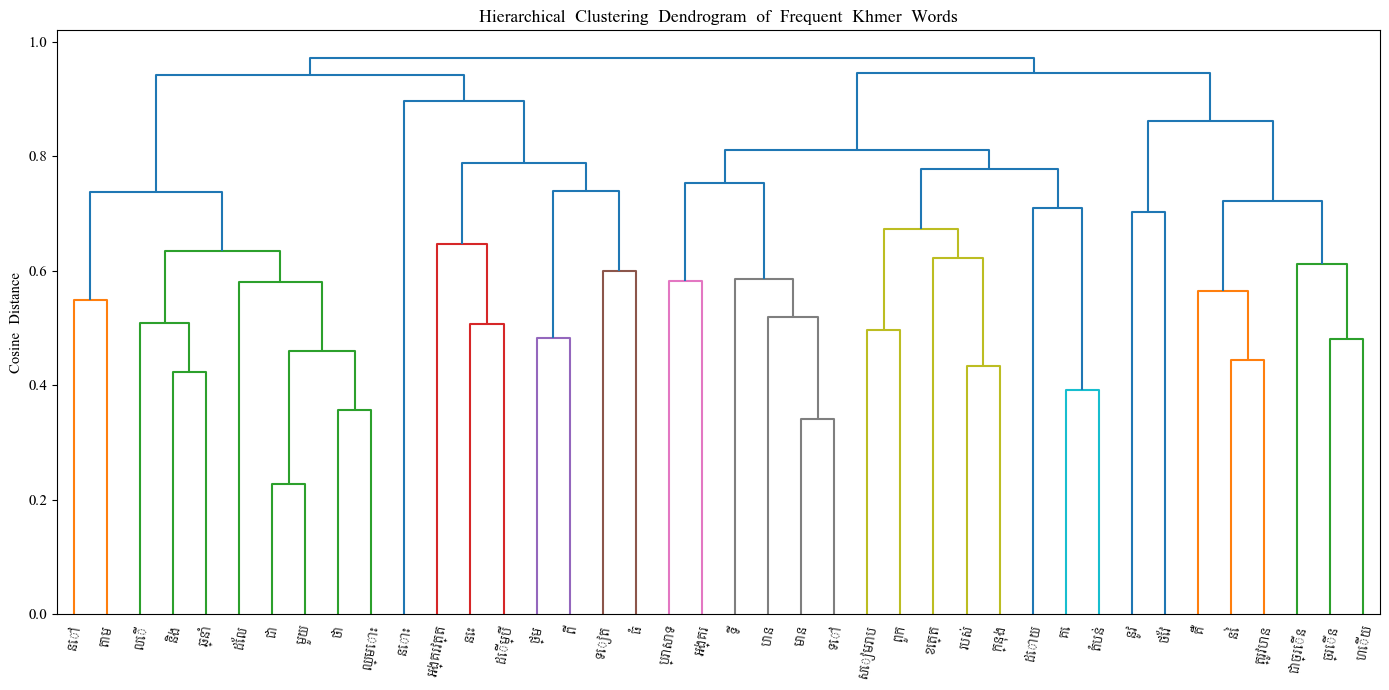

In [30]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
from matplotlib import font_manager


def find_khmer_font():
    preferred_fonts = [
        "Noto Sans Khmer",
        "Noto Serif Khmer",
        "Khmer OS Siemreap",
        "Khmer OS Battambang",
        "Khmer OS Content",
        "Khmer OS",
        "DaunPenh",
        "Leelawadee UI",
    ]

    installed_fonts = font_manager.fontManager.ttflist
    for preferred_font in preferred_fonts:
        for font in installed_fonts:
            if preferred_font.lower() == font.name.lower():
                return font.name

    for preferred_font in preferred_fonts:
        for font in installed_fonts:
            if preferred_font.lower() in font.name.lower():
                return font.name

    return None


def contains_khmer_text(text):
    for character in str(text):
        if "\u1780" <= character <= "\u17FF":
            return True
    return False


khmer_font_name = find_khmer_font()
if khmer_font_name is not None:
    plt.rcParams["font.family"] = [khmer_font_name, "DejaVu Sans"]
    print("Khmer font used:", khmer_font_name)
else:
    print("No Khmer-supported font found. Khmer labels may not display correctly. Please install Noto Sans Khmer or Khmer OS fonts.")
plt.rcParams["axes.unicode_minus"] = False

number_of_dendrogram_words = min(40, len(embedding_df))
selected_words_df = embedding_df.sort_values("frequency", ascending=False).head(number_of_dendrogram_words)
selected_indices = selected_words_df.index.tolist()
selected_vectors = vectors_for_clustering[selected_indices]
selected_words = selected_words_df["word"].astype(str).tolist()

distance_matrix = pdist(selected_vectors, metric="cosine")
linkage_matrix = linkage(distance_matrix, method="average")

plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix, labels=selected_words, leaf_rotation=90, leaf_font_size=12)
plt.title("Hierarchical Clustering Dendrogram of Frequent Khmer Words", fontsize=16, fontname="DejaVu Sans")
plt.ylabel("Cosine Distance", fontsize=12, fontname="DejaVu Sans")
if khmer_font_name is not None:
    for label in plt.gca().get_xticklabels():
        if contains_khmer_text(label.get_text()):
            label.set_fontfamily([khmer_font_name, "DejaVu Sans"])
        else:
            label.set_fontname("DejaVu Sans")
        label.set_fontsize(11)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "hierarchical_dendrogram_khmer.png", dpi=300, bbox_inches="tight")
plt.show()

label_rows = []
numbered_labels = []
for label_index, row in enumerate(selected_words_df.itertuples(), start=1):
    short_id = "W" + str(label_index).zfill(2)
    numbered_labels.append(short_id)
    label_rows.append({
        "ID": short_id,
        "Khmer Word": row.word,
        "Frequency": row.frequency,
    })

dendrogram_word_labels_df = pd.DataFrame(label_rows)
dendrogram_word_labels_df.to_csv(OUTPUT_TABLE_DIR / "dendrogram_word_labels.csv", index=False)

plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix, labels=numbered_labels, leaf_rotation=90, leaf_font_size=12)
plt.title("Hierarchical Clustering Dendrogram of Frequent Khmer Words", fontsize=16, fontname="DejaVu Sans")
plt.ylabel("Cosine Distance", fontsize=12, fontname="DejaVu Sans")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "hierarchical_dendrogram_numbered.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved Khmer dendrogram:", OUTPUT_FIGURE_DIR / "hierarchical_dendrogram_khmer.png")
print("Saved numbered dendrogram:", OUTPUT_FIGURE_DIR / "hierarchical_dendrogram_numbered.png")
print("Saved label mapping table:", OUTPUT_TABLE_DIR / "dendrogram_word_labels.csv")
display(dendrogram_word_labels_df.head(15))

### 18.6 Discussion of Clustering Results

K-means helps group words into clusters, and the silhouette score helps choose a reasonable number of clusters. The PCA cluster map makes the K-means groups easier to visualize, while hierarchical clustering gives a tree-style view of word similarity.

These results are exploratory because the corpus is small and domain-specific. The clusters should not be interpreted as perfect semantic classes; they are better understood as contextual groups learned from the temple corpus.

## 19. Neural LM with Fixed Skip-gram Embeddings

This neural language model predicts the next word from the previous 5 words. It uses the trained skip-gram embeddings as fixed input representations.

In [31]:
class LanguageModelDataset(Dataset):
    def __init__(self, ids, n_context):
        self.contexts = []
        self.targets = []
        for i in range(n_context, len(ids)):
            self.contexts.append(ids[i - n_context:i])
            self.targets.append(ids[i])

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        return (
            torch.tensor(self.contexts[index], dtype=torch.long),
            torch.tensor(self.targets[index], dtype=torch.long),
        )

class NeuralLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_context, hidden_size, pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        if pretrained_embeddings is not None:
            self.embedding.weight.data = torch.tensor(pretrained_embeddings, dtype=torch.float32)
        self.embedding.weight.requires_grad = not freeze_embeddings
        self.hidden = nn.Linear(n_context * embedding_dim, hidden_size)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_size, vocab_size)

    def forward(self, context_ids):
        embedded = self.embedding(context_ids)
        flattened = embedded.reshape(embedded.shape[0], -1)
        hidden_output = self.relu(self.hidden(flattened))
        logits = self.output(hidden_output)
        return logits

def make_lm_loaders(train_ids, valid_ids, test_ids):
    train_dataset = LanguageModelDataset(train_ids, N_CONTEXT)
    valid_dataset = LanguageModelDataset(valid_ids, N_CONTEXT)
    test_dataset = LanguageModelDataset(test_ids, N_CONTEXT)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, valid_loader, test_loader

train_loader_lm, valid_loader_lm, test_loader_lm = make_lm_loaders(train_ids, valid_ids, test_ids)

def evaluate_lm(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    total_items = 0
    correct_top1 = 0
    correct_top5 = 0
    with torch.no_grad():
        for contexts, targets in loader:
            contexts = contexts.to(device)
            targets = targets.to(device)
            logits = model(contexts)
            loss = criterion(logits, targets)
            batch_size = targets.shape[0]
            total_loss = total_loss + loss.item() * batch_size
            total_items = total_items + batch_size
            predictions = torch.argmax(logits, dim=1)
            correct_top1 = correct_top1 + (predictions == targets).sum().item()
            top5 = torch.topk(logits, k=min(5, vocab_size), dim=1).indices
            for row_index in range(targets.shape[0]):
                if targets[row_index].item() in top5[row_index].tolist():
                    correct_top5 = correct_top5 + 1
    average_loss = total_loss / max(total_items, 1)
    perplexity = math.exp(min(average_loss, 20))
    top1_accuracy = correct_top1 / max(total_items, 1)
    top5_accuracy = correct_top5 / max(total_items, 1)
    return average_loss, perplexity, top1_accuracy, top5_accuracy

def train_lm(model, train_loader, valid_loader, epochs, learning_rate):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    history = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_items = 0
        for contexts, targets in train_loader:
            contexts = contexts.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            logits = model(contexts)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            batch_size = targets.shape[0]
            total_loss = total_loss + loss.item() * batch_size
            total_items = total_items + batch_size
        train_loss = total_loss / max(total_items, 1)
        valid_loss, valid_perplexity, valid_top1, valid_top5 = evaluate_lm(model, valid_loader)
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "valid_perplexity": valid_perplexity,
            "valid_top1": valid_top1,
            "valid_top5": valid_top5,
        })
        print("Epoch", epoch + 1, "train loss:", round(train_loss, 4), "valid loss:", round(valid_loss, 4))
    return pd.DataFrame(history)

fixed_lm_model = NeuralLanguageModel(
    vocab_size,
    EMBEDDING_DIM,
    N_CONTEXT,
    HIDDEN_SIZE,
    pretrained_embeddings=skipgram_embedding_matrix,
    freeze_embeddings=True,
).to(device)

fixed_lm_history = train_lm(fixed_lm_model, train_loader_lm, valid_loader_lm, EPOCHS_LM, LEARNING_RATE)
fixed_test_loss, fixed_test_perplexity, fixed_top1, fixed_top5 = evaluate_lm(fixed_lm_model, test_loader_lm)

print("Fixed embedding LM test perplexity:", round(fixed_test_perplexity, 4))
print("Top-1 accuracy:", round(fixed_top1, 4))
print("Top-5 accuracy:", round(fixed_top5, 4))

fig = px.line(fixed_lm_history, x="epoch", y=["train_loss", "valid_loss"], markers=True, title="Fixed Skip-gram Embedding Neural LM Loss")
fig.show()

Epoch 1 train loss: 3.6319 valid loss: 3.5674
Epoch 2 train loss: 3.2557 valid loss: 3.5943
Epoch 3 train loss: 3.0903 valid loss: 3.5771
Epoch 4 train loss: 2.9056 valid loss: 3.5941
Epoch 5 train loss: 2.7154 valid loss: 3.6362
Epoch 6 train loss: 2.5181 valid loss: 3.6781
Epoch 7 train loss: 2.3349 valid loss: 3.7672
Epoch 8 train loss: 2.1594 valid loss: 3.8178
Epoch 9 train loss: 2.0053 valid loss: 3.9151
Epoch 10 train loss: 1.8499 valid loss: 4.0304
Epoch 11 train loss: 1.7191 valid loss: 4.0941
Epoch 12 train loss: 1.5938 valid loss: 4.2277
Epoch 13 train loss: 1.4884 valid loss: 4.2521
Epoch 14 train loss: 1.3782 valid loss: 4.4284
Epoch 15 train loss: 1.2902 valid loss: 4.4681
Epoch 16 train loss: 1.2006 valid loss: 4.5994
Epoch 17 train loss: 1.1302 valid loss: 4.6794
Epoch 18 train loss: 1.0567 valid loss: 4.7801
Epoch 19 train loss: 0.987 valid loss: 4.8732
Epoch 20 train loss: 0.9321 valid loss: 4.9727
Fixed embedding LM test perplexity: 115.0986
Top-1 accuracy: 0.3589
To

## 20. Neural LM Learning Embeddings from Scratch

This model has the same architecture, but its embedding layer starts randomly and is learned during next-word prediction training.

In [32]:
scratch_lm_model = NeuralLanguageModel(
    vocab_size,
    EMBEDDING_DIM,
    N_CONTEXT,
    HIDDEN_SIZE,
    pretrained_embeddings=None,
    freeze_embeddings=False,
).to(device)

scratch_lm_history = train_lm(scratch_lm_model, train_loader_lm, valid_loader_lm, EPOCHS_LM, LEARNING_RATE)
scratch_test_loss, scratch_test_perplexity, scratch_top1, scratch_top5 = evaluate_lm(scratch_lm_model, test_loader_lm)

print("Scratch embedding LM test perplexity:", round(scratch_test_perplexity, 4))
print("Top-1 accuracy:", round(scratch_top1, 4))
print("Top-5 accuracy:", round(scratch_top5, 4))

fig = px.line(scratch_lm_history, x="epoch", y=["train_loss", "valid_loss"], markers=True, title="Scratch Embedding Neural LM Loss")
fig.show()

Epoch 1 train loss: 3.6362 valid loss: 3.5732
Epoch 2 train loss: 3.0989 valid loss: 3.5477
Epoch 3 train loss: 2.8145 valid loss: 3.5522
Epoch 4 train loss: 2.5126 valid loss: 3.5858
Epoch 5 train loss: 2.212 valid loss: 3.6287
Epoch 6 train loss: 1.9333 valid loss: 3.7291
Epoch 7 train loss: 1.6715 valid loss: 3.871
Epoch 8 train loss: 1.447 valid loss: 4.0405
Epoch 9 train loss: 1.2473 valid loss: 4.1899
Epoch 10 train loss: 1.0817 valid loss: 4.3322
Epoch 11 train loss: 0.9423 valid loss: 4.469
Epoch 12 train loss: 0.8237 valid loss: 4.6634
Epoch 13 train loss: 0.7268 valid loss: 4.8295
Epoch 14 train loss: 0.6472 valid loss: 4.9373
Epoch 15 train loss: 0.5801 valid loss: 5.0972
Epoch 16 train loss: 0.5268 valid loss: 5.2381
Epoch 17 train loss: 0.4809 valid loss: 5.3682
Epoch 18 train loss: 0.4404 valid loss: 5.5348
Epoch 19 train loss: 0.4146 valid loss: 5.5868
Epoch 20 train loss: 0.3883 valid loss: 5.7645
Scratch embedding LM test perplexity: 229.0701
Top-1 accuracy: 0.3545
Top

**Interpretation:** The scratch model learns embeddings specifically for next-word prediction. If validation loss increases while train loss decreases, the model is overfitting the small corpus.

## 21. PCA of Scratch LM Embeddings

Now we visualize the embeddings learned from scratch by the neural language model.

In [33]:
scratch_embedding_matrix = scratch_lm_model.embedding.weight.detach().cpu().numpy()
pca_scratch = PCA(n_components=2, random_state=RANDOM_SEED)
scratch_2d = pca_scratch.fit_transform(scratch_embedding_matrix)

pca_scratch_df = pd.DataFrame({
    "word": idx2word,
    "PC1": scratch_2d[:, 0],
    "PC2": scratch_2d[:, 1],
    "frequency": word_frequencies,
})

print("Explained variance ratio:", pca_scratch.explained_variance_ratio_)

fig = px.scatter(
    pca_scratch_df,
    x="PC1",
    y="PC2",
    hover_data=["word", "frequency"],
    size=np.maximum(pca_scratch_df["frequency"], 1),
    title="PCA Map of Scratch Neural LM Embeddings",
    labels={"PC1": "Principal Component 1", "PC2": "Principal Component 2"},
)
fig.show()

Explained variance ratio: [0.04159391 0.03872879]


**Interpretation:** Skip-gram embeddings are trained to capture context similarity directly. Scratch neural LM embeddings are trained to help predict the next word, so their geometry can be different.

## 22. Model Comparison

The table compares the n-gram baseline, the neural LM with fixed skip-gram embeddings, and the neural LM with scratch embeddings.

In [34]:
comparison_rows = [
    {
        "Model": "N-gram baseline",
        "Embedding Source": "No embeddings",
        "Train Loss": None,
        "Validation Loss": None,
        "Test Perplexity": ngram_test_perplexity,
        "Top-1 Accuracy": None,
        "Top-5 Accuracy": None,
        "Notes": "Add-one smoothing; stable for small corpus",
    },
    {
        "Model": "Neural LM fixed",
        "Embedding Source": "Skip-gram embeddings fixed",
        "Train Loss": fixed_lm_history.iloc[-1]["train_loss"],
        "Validation Loss": fixed_lm_history.iloc[-1]["valid_loss"],
        "Test Perplexity": fixed_test_perplexity,
        "Top-1 Accuracy": fixed_top1,
        "Top-5 Accuracy": fixed_top5,
        "Notes": "Uses semantic vectors but does not update embeddings",
    },
    {
        "Model": "Neural LM scratch",
        "Embedding Source": "Learned from scratch",
        "Train Loss": scratch_lm_history.iloc[-1]["train_loss"],
        "Validation Loss": scratch_lm_history.iloc[-1]["valid_loss"],
        "Test Perplexity": scratch_test_perplexity,
        "Top-1 Accuracy": scratch_top1,
        "Top-5 Accuracy": scratch_top5,
        "Notes": "Learns task-specific embeddings",
    },
]

model_comparison_df = pd.DataFrame(comparison_rows)
model_comparison_df

,Model,Embedding Source,Train Loss,Validation Loss,Test Perplexity,Top-1 Accuracy,Top-5 Accuracy,Notes
0,N-gram baseline,No embeddings,NaN,NaN,158.837698,NaN,NaN,Add-one smoothing; stable for small corpus
1,Neural LM fixed,Skip-gram embeddings fixed,0.932140,4.972656,115.098635,0.358880,0.523950,Uses semantic vectors but does not update embe...
2,Neural LM scratch,Learned from scratch,0.388319,5.764476,229.070119,0.354458,0.523213,Learns task-specific embeddings


**Honest interpretation:** If the neural language model performs worse than the n-gram baseline, that is not a failure. This corpus is small and domain-specific. Neural models can overfit, while n-gram smoothing can be stable on small data. Embeddings are still useful because they create semantic word representations for similarity and visualization.

## 23. Embedding Comparison

This section compares nearest words from skip-gram embeddings and scratch LM embeddings for the same query words.

In [35]:
scratch_similarity_matrix = cosine_similarity(scratch_embedding_matrix)

def get_nearest_words_from_matrix(word, matrix, top_k=10):
    if word not in word2idx:
        return []
    word_id = word2idx[word]
    similarities = matrix[word_id]
    ranked_ids = np.argsort(-similarities)
    nearest = []
    for other_id in ranked_ids:
        if other_id == word_id:
            continue
        nearest.append(idx2word[other_id])
        if len(nearest) >= top_k:
            break
    return nearest

embedding_comparison_rows = []
for query in query_words:
    skip_words = get_nearest_words_from_matrix(query, similarity_matrix, top_k=5)
    scratch_words = get_nearest_words_from_matrix(query, scratch_similarity_matrix, top_k=5)
    embedding_comparison_rows.append({
        "query_word": query,
        "skipgram_nearest": ", ".join(skip_words) if skip_words else "Not in vocab",
        "scratch_lm_nearest": ", ".join(scratch_words) if scratch_words else "Not in vocab",
    })

embedding_comparison_df = pd.DataFrame(embedding_comparison_rows)
embedding_comparison_df

,query_word,skipgram_nearest,scratch_lm_nearest
0,ប្រាសាទ,"គឺជា, សតវត្ស, ប្រទេស, តំណាង, នឹង","អោយ, រចនាបថ, ប្រើ, ទេវតា, ថ្ងៃ"
1,អង្គរ,"លោក, ទៅ, ផ្នែក, ប្រទេស, គឺជា","ខាងក្នុង, លើ, នេះ, ថែវ, កណ្ដាល"
2,អង្គរវត្ត,"សាសនា, សតវត្ស, បុរាណ, នានា, ស្រាល","ទៀត, ពីរ, វិញ, នីមួយ, បុរាណ"
3,សៀមរាប,"ពួក, ខេត្ត, ថ្ងៃ, រួម, អាច","បី, ទាំងអស់, <UNK>, លក្ខណៈ, ថែវ"
4,ព្រះ,Not in vocab,Not in vocab
5,វត្ត,Not in vocab,Not in vocab
6,ខ្មែរ,"ថ្ងៃ, ព្រះបាទ, ចំពោះ, សតវត្ស, នៃ","នៅលើ, ចុង, លៀន, នីមួយ, ខ្លះ"
7,កម្ពុជា,"ខាងក្នុង, នឹង, ថ្ម, យ៉ាង, នូវ","ភ្នំ, សម័យ, ម៉ែត្រ, ដី, ហៅ"
8,សាសនា,"នេះ, អង្គរវត្ត, នានា, បុរាណ, ប៉ុន្តែ","ស្ថាបត្យកម្ម, ត្រូវបាន, នេះ, គឺជា, ទេសចរណ៍"
9,អប្សរា,Not in vocab,Not in vocab


**Interpretation:** Skip-gram learns context relationships directly. Scratch LM embeddings learn features useful for predicting the next word, so they may group words differently.

## 24. Error Analysis

The examples below show where the scratch neural language model predicts correctly or incorrectly.

In [36]:
def collect_prediction_examples(model, loader, max_examples=20):
    model.eval()
    examples = []
    with torch.no_grad():
        for contexts, targets in loader:
            contexts = contexts.to(device)
            targets = targets.to(device)
            logits = model(contexts)
            predictions = torch.argmax(logits, dim=1)
            for row_index in range(contexts.shape[0]):
                context_words = []
                for word_id in contexts[row_index].cpu().tolist():
                    context_words.append(idx2word[word_id])
                true_word = idx2word[targets[row_index].item()]
                predicted_word = idx2word[predictions[row_index].item()]
                examples.append({
                    "context_words": " ".join(context_words),
                    "true_next_word": true_word,
                    "predicted_next_word": predicted_word,
                    "correct": true_word == predicted_word,
                })
                if len(examples) >= max_examples:
                    return pd.DataFrame(examples)
    return pd.DataFrame(examples)

prediction_examples_df = collect_prediction_examples(scratch_lm_model, test_loader_lm, max_examples=20)
prediction_examples_df

,context_words,true_next_word,predicted_next_word,correct
0,ប្រាសាទ បុរាណ <UNK> ទៀត ជាច្រើន,<UNK>,<UNK>,True
1,បុរាណ <UNK> ទៀត ជាច្រើន <UNK>,នេះ,<UNK>,False
2,<UNK> ទៀត ជាច្រើន <UNK> នេះ,ក្រុង,បាន,False
3,ទៀត ជាច្រើន <UNK> នេះ ក្រុង,សៀមរាប,<UNK>,False
4,ជាច្រើន <UNK> នេះ ក្រុង សៀមរាប,កំពុង,នៃ,False
5,<UNK> នេះ ក្រុង សៀមរាប កំពុង,<UNK>,<UNK>,True
6,នេះ ក្រុង សៀមរាប កំពុង <UNK>,<UNK>,<UNK>,True
7,ក្រុង សៀមរាប កំពុង <UNK> <UNK>,ជា,<UNK>,False
8,សៀមរាប កំពុង <UNK> <UNK> ជា,ក្រុង,<UNK>,False
9,កំពុង <UNK> <UNK> ជា ក្រុង,<UNK>,<UNK>,True


**Error discussion:** Common errors may come from named entities, rare words converted to `<UNK>`, Khmer tokenization ambiguity, and the small size of `temples.txt`. High-frequency words can dominate predictions.

**Honest interpretation:** The best model should be identified from the actual comparison table above. If the fixed skip-gram neural LM has the best test perplexity, it suggests the skip-gram embeddings helped next-word prediction. If the scratch LM has lower training loss but worse validation or test performance, it is probably overfitting. If the n-gram baseline performs best, that is also reasonable because small data can favor simpler frequency-based models. The results should not be overclaimed.


## 26. Limitations

- `temples.txt` is a small corpus.
- The corpus is domain-specific to temples and Angkor-related text.
- Khmer tokenization can still be imperfect.
- `MIN_FREQ = 10` may remove rare but meaningful words.
- PCA reduces 50 dimensions to 2 dimensions and loses information.
- Neural language models need more data to generalize well.

## 27. Conclusion

This project successfully implements Khmer word embeddings using skip-gram and negative sampling. It applies PCA to visualize word meaning, builds an n-gram baseline, builds neural language models for next-word prediction, and compares fixed skip-gram embeddings with scratch learned embeddings. The notebook connects course lessons from preprocessing to word meaning and language modeling.

In addition to the required Mini Project 3 tasks, K-means and hierarchical clustering were added as advanced embedding exploration. These methods helped inspect whether learned Khmer word embeddings form contextual groups.


## 28. 4-Page Report Summary

### Introduction
This mini project studies Khmer word embeddings using a temple-related Khmer text corpus. The main goal is to convert unstructured Khmer text into meaningful word vectors and to use those vectors in language modeling. Khmer is challenging because word boundaries are often not marked by spaces, so tokenization is an important part of the project.

### Methodology
The corpus is loaded from `temples.txt`, cleaned, and tokenized using `khmernltk` when available. A dictionary and regex fallback are included to avoid the weak `.split()` tokenizer problem. Punctuation tokens such as `។` and `ៗ`, number-only tokens, non-Khmer noise, and abnormal very long tokens are removed before vocabulary construction. After token filtering, words with frequency below 10 are mapped to `<UNK>` as required by the project instruction. A skip-gram model with embedding dimension 50, context window +/-4, and 2 negative samples is trained using PyTorch. PCA reduces the learned vectors to 2 dimensions for visualization. A 5-word add-one smoothed n-gram model is used as a baseline. Two neural language models predict the next word from the previous 5 words: one uses fixed skip-gram embeddings and one learns embeddings from scratch. Both use a hidden layer of size 512 and ReLU.

### Results
The tokenizer successfully produces meaningful Khmer tokens, and the final vocabulary excludes punctuation-only and number-only tokens. The vocabulary validation shows that important Khmer temple words are mostly covered, while some low-frequency or compound words are mapped to `<UNK>` because `MIN_FREQ = 10` is mandatory. Skip-gram training produces a 50-dimensional embedding matrix. PCA maps show approximate semantic neighborhoods. The language-model comparison reports test perplexity and top-k accuracy for the n-gram baseline, fixed-embedding neural LM, and scratch neural LM.

### Discussion
The `<UNK>` rate can be high because the corpus is small, domain-specific, and contains many rare names, historical terms, spelling variants, and compound Khmer words. This is a limitation of the dataset and required threshold, not necessarily a coding error. If the fixed skip-gram embedding LM performs best, it means pretrained context embeddings helped the neural LM. If the scratch LM has lower training loss but worse validation or test performance, it indicates overfitting and shows that scratch embeddings need more data. PCA visualization is useful, but it compresses 50 dimensions into 2 dimensions and should be interpreted carefully.

### Conclusion
The project satisfies the Mini Project 3 requirements by building Khmer skip-gram embeddings, applying PCA, building neural language models, learning scratch embeddings, and comparing all results. The final notebook is reproducible, honest about limitations, and suitable for professor review.


## 29. Save Outputs

The notebook saves cleaned tokens, vocabulary, frequencies, embeddings, mappings, model comparison, prediction examples, and PyTorch model files.

In [37]:
output_dir = Path("outputs")
figure_dir = output_dir / "figures"
table_dir = output_dir / "tables"
embedding_dir = output_dir / "embeddings"
model_dir = Path("models")
report_dir = Path("reports")

for directory in [output_dir, figure_dir, table_dir, embedding_dir, model_dir, report_dir]:
    directory.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"token": useful_tokens}).to_csv(table_dir / "cleaned_tokens.csv", index=False, encoding="utf-8-sig")
pd.DataFrame({"word": idx2word, "id": list(range(len(idx2word))), "frequency": word_frequencies}).to_csv(table_dir / "vocabulary.csv", index=False, encoding="utf-8-sig")
token_freq_df.to_csv(table_dir / "token_frequency.csv", index=False, encoding="utf-8-sig")
model_comparison_df.to_csv(table_dir / "model_comparison.csv", index=False, encoding="utf-8-sig")
prediction_examples_df.to_csv(table_dir / "prediction_examples.csv", index=False, encoding="utf-8-sig")

np.save(embedding_dir / "skipgram_embeddings.npy", skipgram_embedding_matrix)
np.save(embedding_dir / "scratch_lm_embeddings.npy", scratch_embedding_matrix)

with open(embedding_dir / "word2idx.json", "w", encoding="utf-8") as file:
    json.dump(word2idx, file, ensure_ascii=False, indent=2)

idx2word_dict = {}
for index, word in enumerate(idx2word):
    idx2word_dict[str(index)] = word

with open(embedding_dir / "idx2word.json", "w", encoding="utf-8") as file:
    json.dump(idx2word_dict, file, ensure_ascii=False, indent=2)

torch.save(skipgram_model.state_dict(), model_dir / "skipgram_model.pt")
torch.save(fixed_lm_model.state_dict(), model_dir / "neural_lm_fixed.pt")
torch.save(scratch_lm_model.state_dict(), model_dir / "neural_lm_scratch.pt")

# Keep descriptive filenames too, for readability.
torch.save(skipgram_model.state_dict(), model_dir / "skipgram_negative_sampling.pt")
torch.save(fixed_lm_model.state_dict(), model_dir / "fixed_skipgram_neural_lm.pt")
torch.save(scratch_lm_model.state_dict(), model_dir / "scratch_neural_lm.pt")

print("Saved updated cleaned outputs and model files successfully.")


Saved updated cleaned outputs and model files successfully.


## 30. GitHub Readiness

This notebook is designed for GitHub submission with:

- `README.md`
- `requirements.txt`
- `.gitignore`
- `outputs/`, `models/`, and `reports/` folders
- Optional Streamlit future deployment starter

## 31. Streamlit Future Deployment Plan

Future app title: **Khmer Temple NLP Explorer**

Sidebar navigation:

1. Corpus Overview
2. EDA Dashboard
3. Word Embedding Explorer
4. PCA Map
5. Next Word Prediction
6. Model Comparison
7. About Project

Planned features:

- Load Khmer text.
- Show preprocessing results.
- Display top frequent words.
- Search a Khmer word and show nearest words.
- Display PCA embedding map.
- Predict next word from 5 previous Khmer words.
- Compare model results.

## 32. Final Quality Audit

| Requirement | Completed? | Evidence |
|---|---|---|
| Khmer tokenizer works | Yes | Section 8 tokenization quality report |
| Punctuation removed | Yes | Sections 9-10 remove Khmer punctuation such as `។` and `ៗ` |
| Meaningful vocabulary | Yes | Section 12 vocabulary is built from cleaned Khmer tokens |
| MIN_FREQ=10 applied | Yes | `MIN_FREQ = 10` and vocabulary construction |
| `<UNK>` rate explained | Yes | Section 13, Discussion, Limitations, and Report Summary |
| Important words covered honestly | Mostly | Section 12 explains missing low-frequency or compound words |
| Embedding dimension=50 | Yes | `EMBEDDING_DIM = 50` |
| Window=+/-4 | Yes | `WINDOW_SIZE = 4` and skip-gram pair construction |
| Negative sampling=2 | Yes | `NEGATIVE_SAMPLES = 2` |
| PCA skip-gram done | Yes | Section 17 |
| Neural LM n=5, h=512 done | Yes | Sections 19-20 |
| Scratch embedding LM done | Yes | Section 20 |
| Comparison done | Yes | Sections 22-23 |
| 4-page report summary done | Yes | Section 28 |
| GitHub/Streamlit plan done | Yes | Sections 30-31 |
